# 04 — Using the emulators through `cloelib`

The *Euclid* likelihood `cloelike` is built on the `cloelib` library, which exposes every emulator of this release
through its `Perturbations` protocol: a class per cosmology, an inner class per spectrum, and the same
`matter_power_spectrum(z, k)` call as the CAMB and CLASS back-ends, so the emulators are a drop-in replacement.
This notebook needs `cloelib` (and `camb` for the comparison); for the dependency-free interface see
`01_quickstart_standalone.ipynb`.

| Class | Cosmology | Inputs beyond ΛCDM (on the `Background`) | Neutrino variants (`N_mnu`) |
|---|---|---|---|
| `CosmoPowerJAXLCDMPerturbations` | ΛCDM | — | 0, 1, 2, 3 |
| `CosmoPowerJAXwCDMPerturbations` | wCDM | `w0` | 0, 1, 2, 3 |
| `CosmoPowerJAXw0waCDMPerturbations` | w0waCDM | `w0`, `wa` | 0, 1, 2, 3 |
| `CosmoPowerJAXLCDMCurvaturePerturbations` | ΛCDM + Ωk | `Omega_k0` | 0, 1, 3 |
| `CosmoPowerJAXw0waCurvaturePerturbations` | w0waCDM + Ωk | `Omega_k0`, `w0`, `wa` | 0, 1, 3 |
| `CosmoPowerJAXLCDMRunningIndexPerturbations` | ΛCDM + αs | `alpha_s` | 0, 1, 3 |
| `CosmoPowerJAXw0waRunningIndexPerturbations` | w0waCDM + αs | `alpha_s`, `w0`, `wa` | 0, 1, 3 |

| Inner class | Spectrum | Available on |
|---|---|---|
| `Linear` | linear $P(k,z)$ | all cosmologies |
| `NonLinear` | nonlinear $P(k,z)$, HMCode2020 with baryonic feedback `log10TAGN` | all cosmologies |
| `NonLinearHalofit` | nonlinear $P(k,z)$, Halofit (Takahashi 2012), gravity only | ΛCDM, wCDM, w0waCDM |

Each inner class returns the total-matter spectrum through `matter_power_spectrum(z, k)` and the CDM + baryon
spectrum through `matter_power_spectrum_cb(z, k)` (loaded from the paired `-cb-` emulator at construction),
and carries `sigma8`, `fsigma8`, `growth_factor(z, k)`, `growth_factor_cb(z, k)` and `growth_rate()`. The inputs
are validated against the training box.

`cloelib` downloads each emulator file it needs from this GitHub repository (raw file URL) and caches it next
to the package. The first cell below serves the files from the local checkout instead, and translates the
pre-release names that `cloelib` may still request (`lcdm-linear.npz` for the massless variant,
`wcdm-1mass-nolinear.npz`) to the released ones (`lcdm-0mass-linear.npz`, `wcdm-1mass-nonlinear.npz`).

In [1]:
import os, glob, timeit
import numpy as np
import matplotlib.pyplot as plt

import cloelib.cosmology.cosmopower_jax_cosmology as cpjc
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations
from cloelib.cosmology.cosmopower_jax_cosmology import (
    CosmoPowerJAXLCDMPerturbations,
    CosmoPowerJAXwCDMPerturbations,
    CosmoPowerJAXw0waCDMPerturbations,
    CosmoPowerJAXLCDMCurvaturePerturbations,
    CosmoPowerJAXLCDMRunningIndexPerturbations,
)

# --- serve the emulator files from this repository instead of downloading them from Zenodo ---------------
EMU_DIR = next(p for p in ["../emulators", "emulators"] if os.path.isdir(p))
_local = {os.path.basename(p): p for p in glob.glob(os.path.join(EMU_DIR, "**", "*.npz"), recursive=True)}
_zenodo = cpjc.emulator_data

# cloelib (October 2026) still asks for the pre-release file names; map them to the released ones.
ALIASES = {f"{fam}-{prod}.npz": f"{fam}-0mass-{prod}.npz"
           for fam in ("lcdm", "wcdm", "w0wa") for prod in ("linear", "nonlinear", "cb-linear", "cb-nonlinear", "s8-fs8")}
ALIASES.update({"wcdm-1mass-nolinear.npz": "wcdm-1mass-nonlinear.npz", "wcdm-1mass-cb-nolinear.npz": "wcdm-1mass-cb-nonlinear.npz"})

def emulator_data_from_repo(filename, base_url=None):
    """Return the local copy of an emulator file if the repository has it, else fall back to cloelib's download."""
    filename = ALIASES.get(filename, filename)
    return _local[filename] if filename in _local else _zenodo(filename, base_url)

cpjc.emulator_data = emulator_data_from_repo
print(f"{len(_local)} emulator files available from {os.path.abspath(EMU_DIR)}")

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})
zs = np.array([0.0, 0.5, 1.0, 2.0])
ks = np.logspace(-4, 1, 300)          # Mpc^-1

# Planck-2018-like fiducial cosmology in cloelib's Background convention
cosmo = dict(H0=67.4, Omega_b0=0.0493, Omega_cdm0=0.2642, Omega_k0=0.0, As=2.1e-9, ns=0.965,
             mnu=0.06, w0=-1.0, wa=0.0, gamma_MG=0.0, N_mnu=1)
print("setup complete")

197 emulator files available from /Users/ivan/Desktop/dr1-matter-emulators/emulators
setup complete


## 1. Linear $P(k)$: emulator versus CAMB

`CAMBBackground` holds the cosmology; the perturbation classes take it plus the redshifts at which spectra are
needed. The emulator class and the CAMB class are called identically.

Note: redshifts have been re-sorted (earliest first)


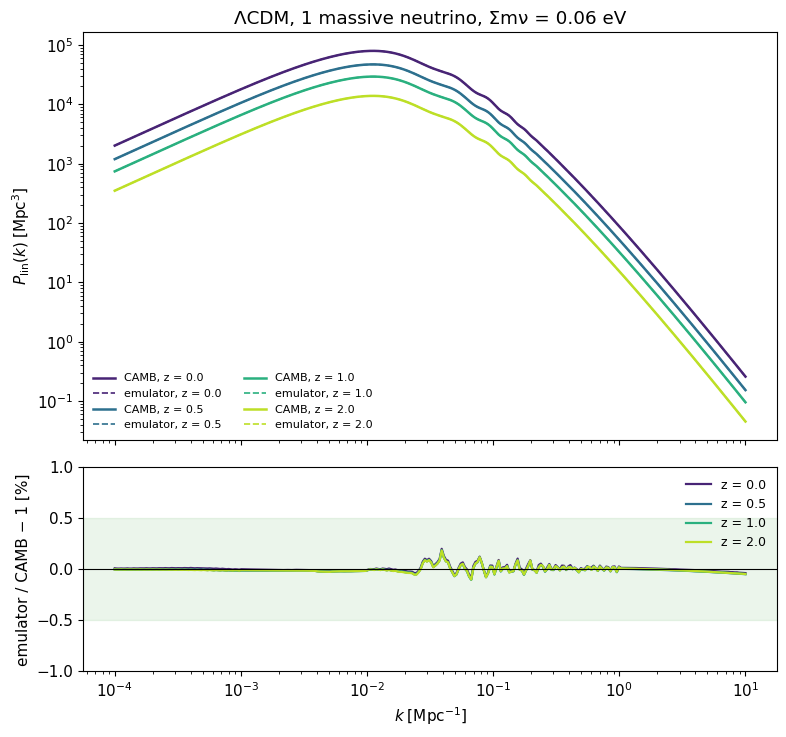

In [2]:
bg = CAMBBackground(**cosmo)
lin_camb = CAMBLinearPerturbations(background=bg, redshifts=zs)
lin_emu  = CosmoPowerJAXLCDMPerturbations.Linear(background=bg, redshifts=zs)

fig, axes = plt.subplots(2, 1, figsize=(8, 7.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(zs)))
for z, c in zip(zs, colors):
    pk_camb = np.squeeze(lin_camb.matter_power_spectrum(z, ks))
    pk_emu  = np.squeeze(lin_emu.matter_power_spectrum(z, ks))
    axes[0].loglog(ks, pk_camb, color=c, lw=1.8, label=f"CAMB, z = {z}")
    axes[0].loglog(ks, pk_emu,  color=c, lw=1.2, ls="--", label=f"emulator, z = {z}")
    axes[1].semilogx(ks, 100 * (pk_emu / pk_camb - 1), color=c, lw=1.6, label=f"z = {z}")
axes[0].set(ylabel=r"$P_{\rm lin}(k)\;[\mathrm{Mpc}^3]$", title="ΛCDM, 1 massive neutrino, Σmν = 0.06 eV"); axes[0].legend(frameon=False, fontsize=8, ncol=2)
axes[1].axhline(0, color="k", lw=0.8); axes[1].axhspan(-0.5, 0.5, color="green", alpha=0.08)
axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel="emulator / CAMB − 1 [%]", ylim=(-1, 1)); axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Total matter versus CDM + baryons

`matter_power_spectrum_cb(z, k)` returns the CDM + baryon spectrum $P_{\rm cb}$ from the paired `-cb-` emulator,
with the same call signature as the total-matter one.

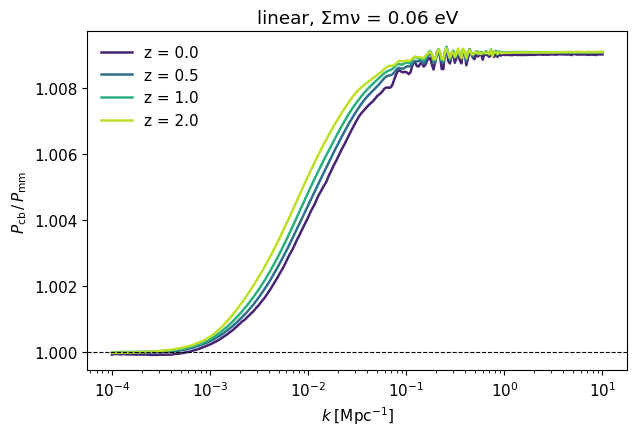

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for z, c in zip(zs, colors):
    ratio = np.squeeze(lin_emu.matter_power_spectrum_cb(z, ks)) / np.squeeze(lin_emu.matter_power_spectrum(z, ks))
    ax.semilogx(ks, ratio, color=c, lw=1.8, label=f"z = {z}")
ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm cb}\,/\,P_{\rm mm}$", title="linear, Σmν = 0.06 eV")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 3. Nonlinear spectra and baryonic feedback

`NonLinear` wraps the HMCode2020 emulator; `log10TAGN` sets the AGN feedback temperature (default 7.6 if not
given). `NonLinearHalofit` is the gravity-only Halofit alternative with the same interface (`log10TAGN` is
accepted and ignored). Both take the linear perturbations object, which they use for the growth quantities.

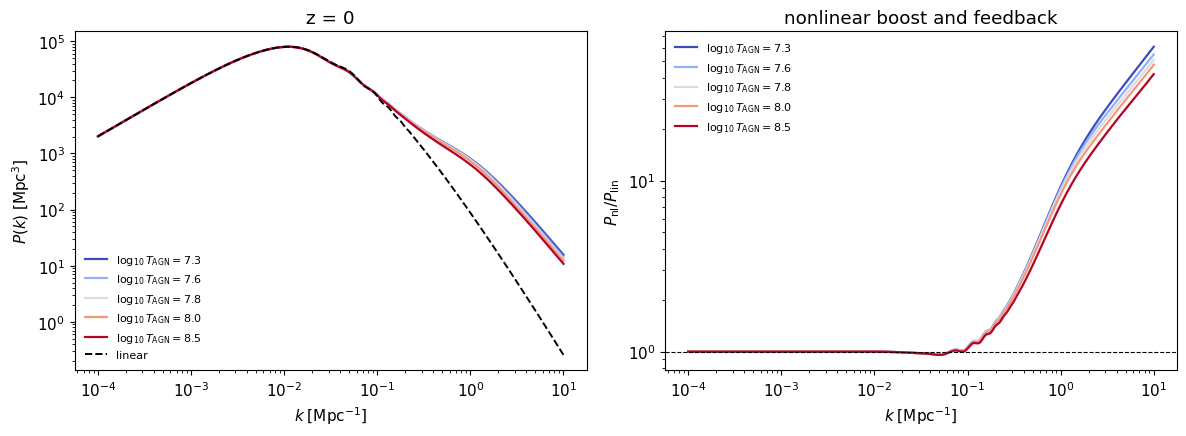

nonlinear P_cb / P_mm at z = 0, k = 1 Mpc^-1 (HMCode2020): 1.0087


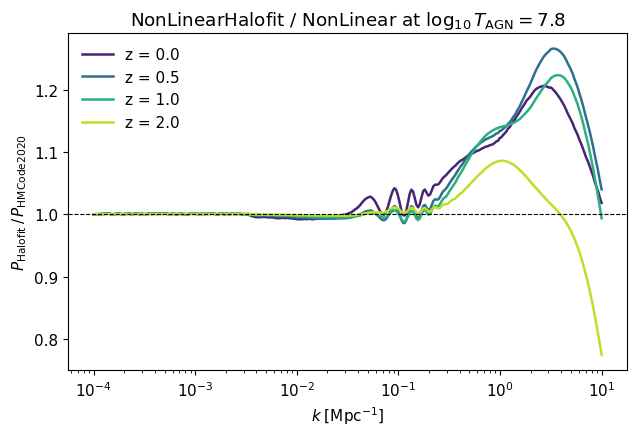

In [4]:
pk_lin0 = np.squeeze(lin_emu.matter_power_spectrum(0.0, ks))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for t, c in zip([7.3, 7.6, 7.8, 8.0, 8.5], plt.cm.coolwarm(np.linspace(0, 1, 5))):
    nl = CosmoPowerJAXLCDMPerturbations.NonLinear(background=bg, linearperturbations=lin_emu, redshifts=zs, log10TAGN=t)
    pk_nl0 = np.squeeze(nl.matter_power_spectrum(0.0, ks))
    axes[0].loglog(ks, pk_nl0, color=c, lw=1.6, label=rf"$\log_{{10}}T_{{\rm AGN}} = {t}$")
    axes[1].semilogx(ks, pk_nl0 / pk_lin0, color=c, lw=1.6, label=rf"$\log_{{10}}T_{{\rm AGN}} = {t}$")
axes[0].loglog(ks, pk_lin0, "k--", lw=1.4, label="linear")
axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P(k)\;[\mathrm{Mpc}^3]$", title="z = 0"); axes[0].legend(frameon=False, fontsize=8)
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}/P_{\rm lin}$", yscale="log", title="nonlinear boost and feedback")
axes[1].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

nl = CosmoPowerJAXLCDMPerturbations.NonLinear(background=bg, linearperturbations=lin_emu, redshifts=zs, log10TAGN=7.8)
nl_hf = CosmoPowerJAXLCDMPerturbations.NonLinearHalofit(background=bg, linearperturbations=lin_emu, redshifts=zs)
print("nonlinear P_cb / P_mm at z = 0, k = 1 Mpc^-1 (HMCode2020):",
      f"{float(np.squeeze(nl.matter_power_spectrum_cb(0.0, np.array([1.0]))) / np.squeeze(nl.matter_power_spectrum(0.0, np.array([1.0])))):.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for z, c in zip(zs, colors):
    ax.semilogx(ks, np.squeeze(nl_hf.matter_power_spectrum(z, ks)) / np.squeeze(nl.matter_power_spectrum(z, ks)), color=c, lw=1.8, label=f"z = {z}")
ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm Halofit}\,/\,P_{\rm HMCode2020}$", title=r"NonLinearHalofit / NonLinear at $\log_{10}T_{\rm AGN}=7.8$")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 4. Dark energy: wCDM and w0waCDM

The dark-energy parameters live on the `Background` (`w0`, and `wa` for the CPL model); the matching class picks
the right emulator file. ΛCDM is recovered at $w_0 = -1$, $w_a = 0$.

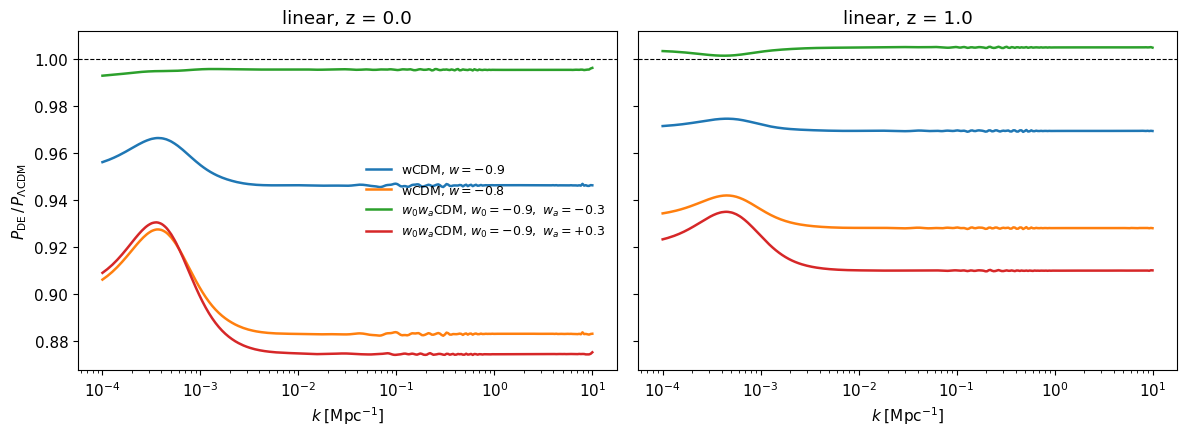

In [5]:
de_models = [
    (CosmoPowerJAXwCDMPerturbations,   dict(w0=-0.9, wa=0.0),  r"wCDM, $w=-0.9$",                  "C0"),
    (CosmoPowerJAXwCDMPerturbations,   dict(w0=-0.8, wa=0.0),  r"wCDM, $w=-0.8$",                  "C1"),
    (CosmoPowerJAXw0waCDMPerturbations, dict(w0=-0.9, wa=-0.3), r"$w_0w_a$CDM, $w_0=-0.9,\ w_a=-0.3$", "C2"),
    (CosmoPowerJAXw0waCDMPerturbations, dict(w0=-0.9, wa=0.3),  r"$w_0w_a$CDM, $w_0=-0.9,\ w_a=+0.3$", "C3"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, z in zip(axes, [0.0, 1.0]):
    p_lcdm = np.squeeze(lin_emu.matter_power_spectrum(z, ks))
    for cls, de, lab, c in de_models:
        bg_de = CAMBBackground(**{**cosmo, **de})
        p = np.squeeze(cls.Linear(background=bg_de, redshifts=zs).matter_power_spectrum(z, ks))
        ax.semilogx(ks, p / p_lcdm, color=c, lw=1.8, label=lab)
    ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", title=f"linear, z = {z}")
axes[0].set_ylabel(r"$P_{\rm DE}\,/\,P_{\Lambda{\rm CDM}}$"); axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Neutrino variants, $\sigma_8(z)$, $f\sigma_8(z)$ and the growth factor

`N_mnu` on the `Background` selects the emulator variant (0: massless, 1: one massive eigenstate, 2 and 3:
degenerate eigenstates). `sigma8` and `fsigma8` are evaluated on the redshifts passed at construction;
`growth_factor(z, k)` is $\sqrt{P(k,z)/P(k,0)}$ and becomes scale-dependent with massive neutrinos.

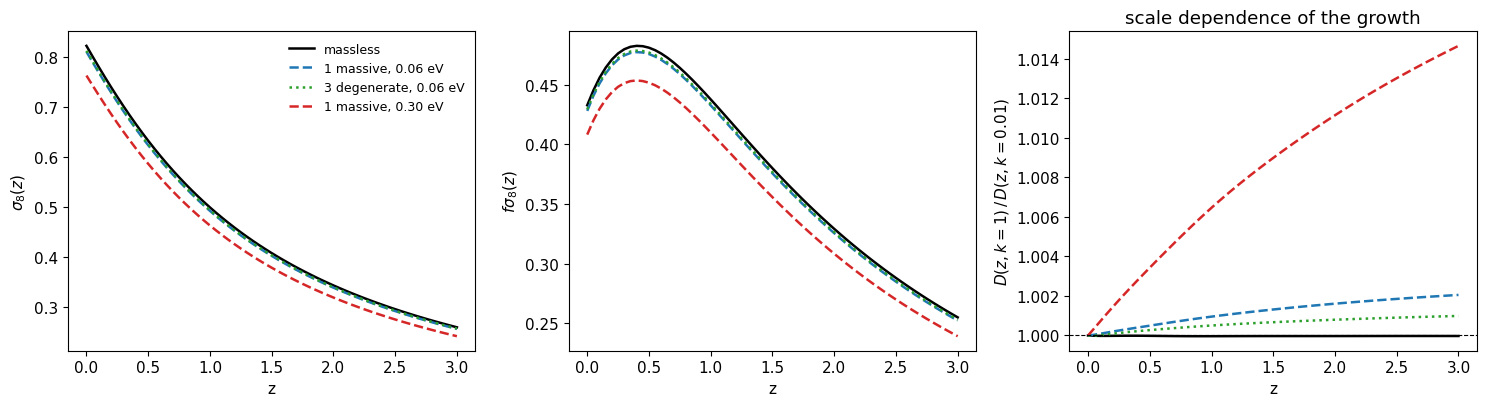

In [6]:
z_fine = np.linspace(0.0, 3.0, 61)
nu_models = [
    (dict(N_mnu=0, mnu=0.0),  r"massless",                    "k",  "-"),
    (dict(N_mnu=1, mnu=0.06), r"1 massive, 0.06 eV",          "C0", "--"),
    (dict(N_mnu=3, mnu=0.06), r"3 degenerate, 0.06 eV",       "C2", ":"),
    (dict(N_mnu=1, mnu=0.30), r"1 massive, 0.30 eV",          "C3", "--"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for pars, lab, c, ls in nu_models:
    lp = CosmoPowerJAXLCDMPerturbations.Linear(background=CAMBBackground(**{**cosmo, **pars}), redshifts=z_fine)
    axes[0].plot(z_fine, lp.sigma8,  color=c, ls=ls, lw=1.8, label=lab)
    axes[1].plot(z_fine, lp.fsigma8, color=c, ls=ls, lw=1.8, label=lab)
    D_large = np.squeeze(lp.growth_factor(z_fine, np.array([0.01])))
    D_small = np.squeeze(lp.growth_factor(z_fine, np.array([1.0])))
    axes[2].plot(z_fine, D_small / D_large, color=c, ls=ls, lw=1.8, label=lab)
axes[0].set(xlabel="z", ylabel=r"$\sigma_8(z)$"); axes[0].legend(frameon=False, fontsize=9)
axes[1].set(xlabel="z", ylabel=r"$f\sigma_8(z)$")
axes[2].axhline(1, color="k", lw=0.8, ls="--"); axes[2].set(xlabel="z", ylabel=r"$D(z, k{=}1)\,/\,D(z, k{=}0.01)$", title="scale dependence of the growth")
plt.tight_layout(); plt.show()

## 6. Extended cosmologies: curvature and running

The curvature and running-index families use the released `curvature-*` and `nrun-*` files. `Omega_k0` and
`alpha_s` are read from the `Background`; the massless, one-massive and three-degenerate variants are available.

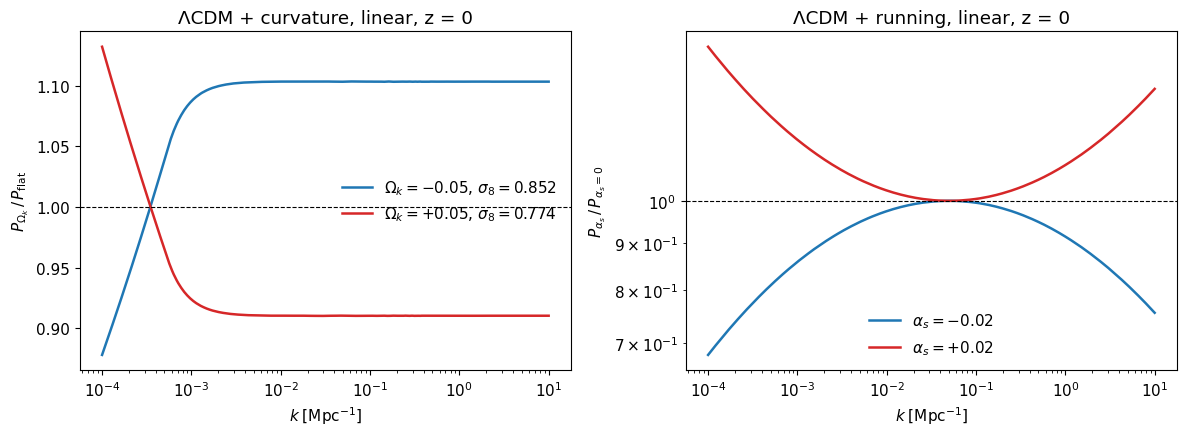

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bg_flat = CAMBBackground(**{**cosmo, "Omega_k0": 0.0})
p_flat = np.squeeze(CosmoPowerJAXLCDMCurvaturePerturbations.Linear(background=bg_flat, redshifts=zs).matter_power_spectrum(0.0, ks))
for omk, c in zip([-0.05, 0.05], ["C0", "C3"]):
    lp = CosmoPowerJAXLCDMCurvaturePerturbations.Linear(background=CAMBBackground(**{**cosmo, "Omega_k0": omk}), redshifts=zs)
    axes[0].semilogx(ks, np.squeeze(lp.matter_power_spectrum(0.0, ks)) / p_flat, color=c, lw=1.8, label=rf"$\Omega_k = {omk:+.2f}$, $\sigma_8 = {lp.sigma8[0]:.3f}$")
axes[0].axhline(1, color="k", lw=0.8, ls="--"); axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\Omega_k}\,/\,P_{\rm flat}$", title="ΛCDM + curvature, linear, z = 0"); axes[0].legend(frameon=False)

p_norun = np.squeeze(CosmoPowerJAXLCDMRunningIndexPerturbations.Linear(background=CAMBBackground(**{**cosmo, "alpha_s": 0.0}), redshifts=zs).matter_power_spectrum(0.0, ks))
for a_s, c in zip([-0.02, 0.02], ["C0", "C3"]):
    lp = CosmoPowerJAXLCDMRunningIndexPerturbations.Linear(background=CAMBBackground(**{**cosmo, "alpha_s": a_s}), redshifts=zs)
    axes[1].semilogx(ks, np.squeeze(lp.matter_power_spectrum(0.0, ks)) / p_norun, color=c, lw=1.8, label=rf"$\alpha_s = {a_s:+.2f}$")
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\alpha_s}\,/\,P_{\alpha_s=0}$", yscale="log", title="ΛCDM + running, linear, z = 0"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 7. Timing: emulator versus CAMB

Each call rebuilds the perturbations object at the fiducial cosmology and evaluates $P(k)$ once, which is what a
likelihood does at every step. The emulator path is timed after one warm-up call (JAX compilation).

In [8]:
N_CAMB, N_EMU = 3, 20

def camb_call():
    b = CAMBBackground(**cosmo)
    CAMBLinearPerturbations(background=b, redshifts=zs).matter_power_spectrum(0.0, ks)

def emu_call():
    b = CAMBBackground(**cosmo)
    CosmoPowerJAXLCDMPerturbations.Linear(background=b, redshifts=zs).matter_power_spectrum(0.0, ks)

emu_call()
t_camb = timeit.timeit(camb_call, number=N_CAMB) / N_CAMB
t_emu  = timeit.timeit(emu_call,  number=N_EMU)  / N_EMU
print(f"CAMB (linear, 4 redshifts)           : {t_camb*1e3:8.1f} ms per call")
print(f"CosmoPower-JAX via cloelib (linear)  : {t_emu*1e3:8.1f} ms per call   (speed-up ×{t_camb/t_emu:.0f})")

Note: redshifts have been re-sorted (earliest first)


Note: redshifts have been re-sorted (earliest first)


Note: redshifts have been re-sorted (earliest first)


CAMB (linear, 4 redshifts)           :    913.1 ms per call
CosmoPower-JAX via cloelib (linear)  :     14.5 ms per call   (speed-up ×63)


## Summary

* Through `cloelib` the emulators behave like any other back-end: build a `Background`, pick the cosmology class
  and inner class, call `matter_power_spectrum(z, k)`.
* The neutrino variant comes from `N_mnu`, the dark-energy parameters from `w0`/`wa`, feedback from `log10TAGN`.
* The emulator classes validate the inputs against the training box, unlike the bare CosmoPower-JAX interface.
* The P_cb spectrum is a method (`matter_power_spectrum_cb`), Halofit a separate inner class, and the curvature
  and running families their own cosmology classes.
* Decaying dark matter and parameterised gravity are not yet wrapped in this `cloelib` version; see notebook `03`.